# Sea ice seasonality statistics: an example in the Southern Ocean

### Background

This recipe calculates number of days of sea ice advance, retreat, and sea ice duration over the sea ice season (February 15 to February 14) in the Southern Ocean using output from ACCESS-OM2-01.

The annual sea ice advance, retreat and total sea ice season duration as defined by [Massom et al 2013](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0064756).  

---

### Requirements

This notebook was generated using a large ARE session, and may not work if run in a session with fewer resources.

For adaptation to `SIS`, which is the sea ice model of some of the PanAntarctic configurations, the following table will help you find equivalent diagnostics:

| CICE diagnostic (x-coord, y-coord) | SIS diagnostic (x-coord, y-coord)|
|---|---|
`aice(ni,nj)` | `siconc(xT, yT)`|

You will **not** need to correct time stamps, and the x, y-coords have longitude, latitude information. Loading of the data will be easier!

In [1]:
import cartopy.crs as ccrs                       
import cmocean.cm as cm                              
import datetime as dt
import intake
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client

Start a dask client:

In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41705,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42973,Total threads: 1
Dashboard: /proxy/38861/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:41553,


## Open sea ice concentration

Open the intake datastore:

In [4]:
catalog = intake.cat.access_nri
experiment = "01deg_jra55v140_iaf_cycle2"

Open sea ice concentration from `CICE`, called `aice` - we can use the `start_date` argument to select just one year. 

There are some recommended kwargs for `xarray` in order to open sea ice data which are described [here](https://github.com/COSIMA/cosima-recipes/blob/main/02-Easy-Recipes/Sea_Ice_Coordinates.ipynb) - lets use those:

In [7]:
xarray_kwargs = {"use_cftime" : True,
                 "decode_coords": False,
                 "decode_timedelta" : False,
                }
    
aice = catalog[experiment].search(variable="aice",
                                           start_date="200[0,1].*"
                                           ).to_dask(xarray_open_kwargs=xarray_kwargs)
# Select only february
aice = aice['aice'].sel(time=slice('2000-02-01','2001-03-01'))

Now we need to apply the correction to the time stamps and longitude/latitude coordinates. `CICE` has an incorrect time stamp and does not come with lat/lon. Again, this is fully described [here](https://github.com/COSIMA/cosima-recipes/blob/main/02-Easy-Recipes/Sea_Ice_Coordinates.ipynb)

In [8]:
# Applying time correction 
aice['time'] = aice.time - dt.timedelta(hours=12)

# Overwrite coordinates used by CICE output:
geolon_t = catalog[experiment].search(variable="geolon_t").to_dask()
geolat_t = catalog[experiment].search(variable="geolat_t").to_dask()

aice.coords['ni'] = geolon_t['xt_ocean'].values
aice.coords['nj'] = geolon_t['yt_ocean'].values
aice = aice.rename(({'ni': 'xt_ocean', 'nj': 'yt_ocean'}))

Now we can subset the Southern Ocean:

In [9]:
aice = aice.sel(yt_ocean=slice(-80,-50))

Select the specific days we are interested in - a sea ice year is defined to be between February 15 and February 14 the following year:

In [11]:
aice = aice.sel(time=slice('2000-02-15', '2001-02-14'))

## Sea ice seasonality calculations

According to the definitions in [Massom et al 2013](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0064756):

 - If sea ice concentration in any grid cell is at least 15% over five consecutive days, sea ice is considered to be *advancing*. 
 - Sea ice is defined to be *retreating* when its concentration is below 15% in any pixel until the end of the sea ice year. 
 - Sea ice *season duration* is the period between day of advance and retreat. 

First, lets find how many days in a year sea ice concentration is above the 15% threshold. Note that `aice` goes from 0 to 1, so the threshold will be 0.15:

In [12]:
min_threshold = 0.15

# Calculate total number of days in year (365 or 366 depending on whether it is a leap year or not):
days_in_year = len(aice.time.values)

# Identify grid cells where sea ice concentration values are equal or above min_threshold.
# Resulting data array is boolean. If concentration > 0.15, then set to True, otherwise set to False:
conc_above_threshold = xr.where(aice >= min_threshold, True, False)

# Add values through time to get total number of days with ice cover of at least 15% within a grid cell:
days_above_threshold = conc_above_threshold.sum('time').compute()

Make a land mask from the bathymetry diagnostic for plotting:

In [13]:
ht = catalog[experiment].search(variable="ht",
                                frequency="fx"
                                ).to_dask()['ht']
ht = ht.sel(yt_ocean=slice(-80,-50))
land = xr.where(np.isnan(ht.rename('land')), 1, np.nan)
# Adjust latitude on land, so it goes to south pole. Needed for prettier plotting:
land_lat = land.yt_ocean.values
land_lat[0] = -90
land['yt_ocean'] = land_lat

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


Plot `days_above_threshold`:

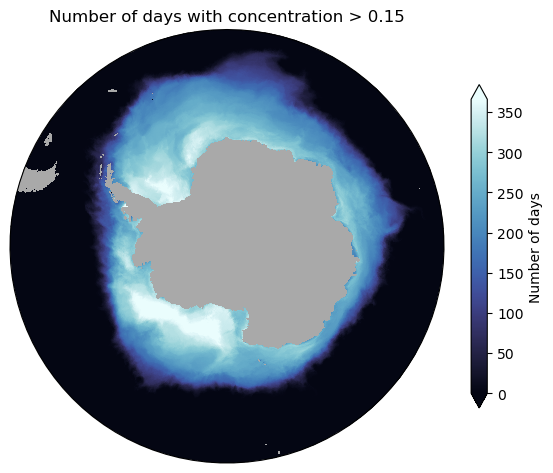

In [17]:
plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([-280, 80, -80, -50], crs=ccrs.PlateCarree())

theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

land.plot.contourf(ax=ax,
                   colors='darkgrey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

days_above_threshold.plot(ax=ax,
                          cmap=cm.ice,
                          transform=ccrs.PlateCarree(),
                          cbar_kwargs={'orientation': 'vertical',
                                       'shrink': 0.6,
                                       'extend': 'both',
                                       'label': 'Number of days'})

ax.set_title('Number of days with concentration > 0.15');

Create some masks that will be useful for the advance, retreat and duration metrics:

1. Mask of cells where sea ice never exceeded the minimum threshold:

In [18]:
noIce = xr.where(days_above_threshold == 0, True, False)

2. Mask of cells where sea ice did not advance - define as not exceeding the threshold for at least 5 consecutive days:

In [19]:
min_days_threshold = 5
noIceAdvance = xr.where(days_above_threshold < min_days_threshold, True, False)

3. Mask of cells where sea ice concentration was *always* above the threshold:

In [20]:
alwaysIce = xr.where(days_above_threshold == days_in_year, True, False)

Now we are ready to calculate advance, retreat and duration.

### Sea ice advance

In [21]:
# Use cumulative sums based on time. If grid cell has sea ice cover below min_threshold, then cumulative sum is reset to zero:
advance = conc_above_threshold.cumsum(dim='time') - conc_above_threshold.cumsum(dim='time').where(conc_above_threshold.values==0).ffill(dim = 'time').fillna(0)
# Note: ffill adds nan values forward over a specific dimension

# Find time index where the minimum consecutive sea ice concentration was first detected for each grid cell
# Change all grid cells that do not meet the minimum consecutive sea ice concentration to False. Otherwise maintain their value.
advanceDate = xr.where(advance==min_days_threshold, advance, False)

# Find the time index where condition above was met:
advanceDate = advanceDate.argmax(dim='time')

# Apply masks of no sea ice advance (noIceAdvance) and sea ice always present (alwaysIce).
advanceDate = advanceDate.where(noIceAdvance==False, np.nan).where(alwaysIce==False, 1).compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 807.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Plot day of year of sea ice advance. Note that this is defined relative to February 15th.

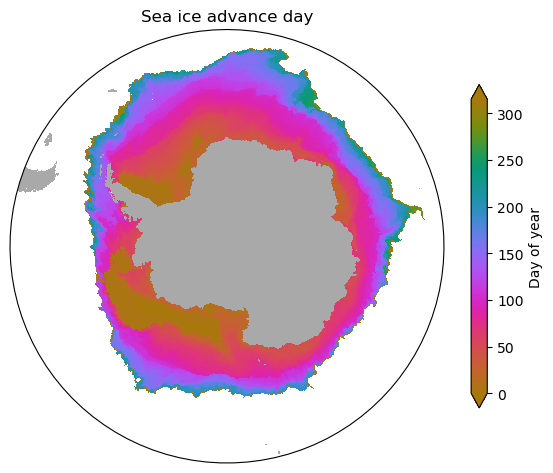

In [22]:
plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([-280, 80, -80, -50], crs=ccrs.PlateCarree())

theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
    
# Filled land 
land.plot.contourf(ax=ax,
                   colors='darkgrey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

advanceDate.plot(ax=ax,
                 cmap=cm.phase,
                 transform=ccrs.PlateCarree(),
                 cbar_kwargs={'orientation': 'vertical',
                              'shrink': 0.6,
                              'extend': 'both',
                              'label': 'Day of year'})

ax.set_title('Sea ice advance day' );

### Sea ice retreat

In [23]:
# Reverse conc_above_threshold in time dimension, so end date is now the start date and calculate cumulative sum over time:
retreat = conc_above_threshold[::-1].cumsum('time')

# Change zero values to 9999 so they are ignored in the next step of our calculation:
retreat = xr.where(retreat == 0, 9999, retreat)

# Find the time index where sea ice concentration changes to above threshold:
retreatDate = retreat.argmin(dim = 'time')

# Substract index from total time length:
retreatDate = days_in_year - retreatDate

# Apply masks of no sea ice over min_threshold (noIce) and sea ice always present (alwaysIce):
retreatDate = retreatDate.where(noIce==False, np.nan).where(alwaysIce==False, days_in_year).compute()

Plot day of year of sea ice retreat. Note that this is defined relative to February 15th.

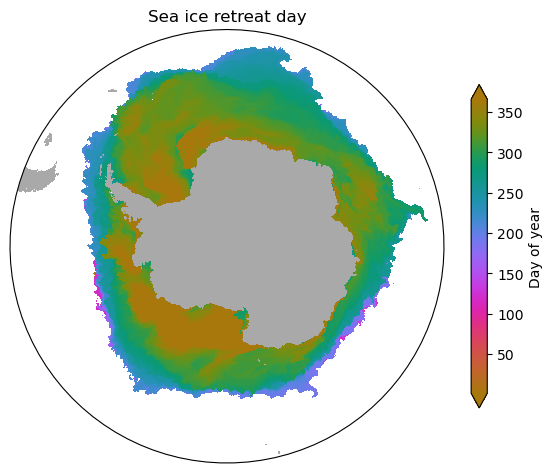

In [24]:
plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([-280, 80, -80, -50], crs=ccrs.PlateCarree())

theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
    
# Filled land 
land.plot.contourf(ax=ax,
                   colors='darkgrey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

retreatDate.plot(ax=ax, 
                 cmap=cm.phase,
                 transform=ccrs.PlateCarree(),
                 cbar_kwargs={'orientation': 'vertical',
                              'shrink': 0.6,
                              'extend': 'both',
                              'label': 'Day of year'})

ax.set_title('Sea ice retreat day');

### Sea ice duration

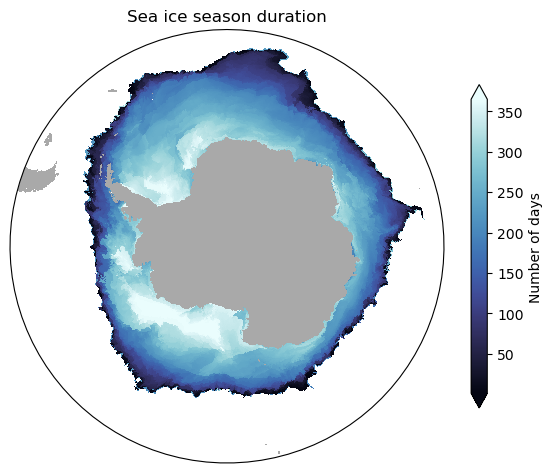

In [25]:
durationDays = retreatDate - advanceDate

plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([-280, 80, -80, -50], crs=ccrs.PlateCarree())

theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
    
# Filled land 
land.plot.contourf(ax=ax,
                   colors='darkgrey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

durationDays.plot(ax=ax,
                  cmap=cm.ice,
                  transform=ccrs.PlateCarree(),
                  cbar_kwargs={'orientation': 'vertical',
                               'shrink': 0.6,
                               'extend': 'both',
                               'label': 'Number of days'})

ax.set_title('Sea ice season duration');